<a href="https://colab.research.google.com/github/MMastando/Portfolio/blob/main/Random_Forest_March_Madness_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#HOW TO USE THIS CODE:

### 1. Run the code as-is to see the 2023 March Madness simulation
### 2. To experiment:
###    - Change the feature weights in SECTION 3 to give more/less importance to different stats
###    - Modify the conference weights in SECTION 3 to change how much conference strength matters
###    - Change the model parameters in SECTION 4 to potentially improve prediction accuracy
###    - Update the tournament matchups in SECTION 5 to simulate different scenarios
### NOTE: For future years, you would need to update the matchups and ensure you have current data!


In [ ]:
# ==================== SECTION 1: IMPORTS ====================
# These are the libraries needed for the program to run
# You don't need to change these unless you want to add new functionality
import kagglehub
import pandas as pd
import os
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler

In [ ]:
# ==================== SECTION 2: DATA LOADING ====================
# This section downloads and loads the college basketball datasets
# You don't need to modify this unless you want to use different data
path = kagglehub.dataset_download("andrewsundberg/college-basketball-dataset")
files = os.listdir(path)
dataframes = {}

for file in files:
    if file.endswith('.csv'):
        df_name = file.replace('.csv', '')
        dataframes[df_name] = pd.read_csv(os.path.join(path, file))

# Fix column naming issues in the data
dataframes['cbb22'].rename(columns={'EFGD_D': 'EFG_D'}, inplace=True)

# Combine all past years data (except the current year - 2023)
past_years = [df for name, df in dataframes.items() if 'cbb' in name and name != 'cbb23']
all_data = pd.concat(past_years)

In [ ]:
# ==================== SECTION 3: FEATURE ENGINEERING ====================
# This section processes the raw data to create useful features for the model
# You can modify the weights below to see how they affect predictions

def preprocess_features(all_data):

    # ===== AREA TO EXPERIMENT: FEATURE WEIGHTS =========================
    # You can change these weights to see how they affect your predictions
    WAB_WEIGHT = 0.80       # Weight for "Wins Above Bubble" metric
    EFFICIENCY_WEIGHT = 2.1  # Weight for offensive and defensive efficiency
    BARTHAG_WEIGHT = 0.8     # Weight for power rating (BARTHAG)
    # ===================================================================

    # First, create adjusted versions of key metrics
    all_data['WAB_adj'] = all_data['WAB'] * WAB_WEIGHT
    all_data['WAB_sign'] = all_data['WAB'].apply(lambda x: 1 if x > 0 else -1)
    all_data['WAB_final'] = all_data['WAB_adj'] * all_data['WAB_sign']

    # Increase importance of efficiency metrics
    all_data['ADJDE'] = all_data['ADJDE'] * EFFICIENCY_WEIGHT
    all_data['ADJOE'] = all_data['ADJOE'] * EFFICIENCY_WEIGHT

    # Calculate net efficiency
    all_data['net_eff'] = all_data['ADJOE'] - all_data['ADJDE']

    # Conference strength calculations
    conf_strength = all_data.groupby('CONF')['net_eff'].mean()
    conf_rank = conf_strength.rank(ascending=True)

    # ===== AREA TO EXPERIMENT: CONFERENCE WEIGHTS =========================
    # You can adjust these values to change how much conference strength matters
    MIN_CONF_WEIGHT = 0.85  # Minimum weight for weakest conference (increase this value if you want weaker conferences to hold more weight!)
    MAX_CONF_WEIGHT = 1.15  # Maximum weight for strongest conference (increase this value if you want stronger conferences to hold more weight!)
    # ======================================================================

    num_conferences = len(conf_rank)
    conf_weight = conf_rank.apply(lambda r: MIN_CONF_WEIGHT + (MAX_CONF_WEIGHT - MIN_CONF_WEIGHT) *
                              ((num_conferences - r) / (num_conferences - 1)))

    # Add conference weights to dataset
    all_data['CONF_WEIGHT'] = all_data['CONF'].map(conf_weight)

    # Special scaling for BARTHAG (team power rating)
    all_data['BARTHAG'] = all_data['BARTHAG'] * BARTHAG_WEIGHT

    # Apply logarithm to WAB to limit its weight
    #all_data['WAB_final'] = np.log1p(all_data['WAB_final'])

    # ===== FEATURES USED IN THE MODEL =====
    # These are the stats that will be used to make predictions
    # You can comment out lines to remove features from the model
    columns_to_standardize = [
        'ADJDE',        # Adjusted Defensive Efficiency
        'ADJOE',        # Adjusted Offensive Efficiency
        'EFG_O',        # Effective Field Goal Percentage (Offense)
        'EFG_D',        # Effective Field Goal Percentage (Defense)
        'TOR',          # Turnover Rate
        'ORB',          # Offensive Rebound Percentage
        'ADJ_T',        # Adjusted Tempo
        'WAB_final',    # Modified Wins Above Bubble
        'BARTHAG',      # Power Rating (projected win percentage for a college basketball team against an average D1 team playing on a neutral court)
        'CONF_WEIGHT'   # Conference Strength Weight
    ]
    # ======================================================================

    # Standardize all features (makes them comparable)
    scaler = StandardScaler()
    all_data[columns_to_standardize] = scaler.fit_transform(all_data[columns_to_standardize])

    return all_data, scaler, conf_weight

In [ ]:
# This function applies the same processing to new data
def preprocess_new_data(new_data, conf_weight, scaler):

    # Create a copy to avoid modifying original data
    new_data = new_data.copy()

    # ===== AREA TO EXPERIMENT: FEATURE WEIGHTS FOR NEW DATA =====
    # These should match the weights in the preprocess_features function
    WAB_WEIGHT = 0.80       # Weight for "Wins Above Bubble" metric
    EFFICIENCY_WEIGHT = 2    # Weight for offensive and defensive efficiency (note: this is different!)
    BARTHAG_WEIGHT = 0.8     # Weight for power rating (BARTHAG)
    # =========================================================

    # Process WAB
    new_data['WAB_adj'] = new_data['WAB'] * WAB_WEIGHT
    new_data['WAB_sign'] = new_data['WAB'].apply(lambda x: 1 if x > 0 else -1)
    new_data['WAB_final'] = new_data['WAB_adj'] * new_data['WAB_sign']

    # Process efficiency metrics
    new_data['ADJDE'] = new_data['ADJDE'] * EFFICIENCY_WEIGHT
    new_data['ADJOE'] = new_data['ADJOE'] * EFFICIENCY_WEIGHT

    # Add conference weights
    new_data['CONF_WEIGHT'] = new_data['CONF'].map(conf_weight)

    # Process BARTHAG
    new_data['BARTHAG'] = new_data['BARTHAG'] * BARTHAG_WEIGHT

    # Select and standardize only the features used in training
    features = ['ADJDE', 'ADJOE', 'EFG_O', 'EFG_D',
                'TOR', 'ORB', 'ADJ_T', 'WAB_final',
                'BARTHAG', 'CONF_WEIGHT']

    new_data_features = new_data[features]
    new_data_features = pd.DataFrame(scaler.transform(new_data_features),
                                   columns=features,
                                   index=new_data.index)

    # Add back the TEAM column for reference
    new_data_features['TEAM'] = new_data['TEAM']

    return new_data_features

In [ ]:
# ==================== SECTION 4: MODEL TRAINING ====================
# This section creates and trains the prediction model
# You can experiment with the model parameters

# Preprocess the historical data
all_data, scaler, conf_weight = preprocess_features(all_data)

# Prepare features for model training
X = all_data[['ADJDE', 'ADJOE', 'EFG_O', 'EFG_D',
              'TOR', 'ORB', 'ADJ_T', 'WAB_final', 'BARTHAG', 'CONF_WEIGHT']]

# Target variable: Did the team make the postseason? (1=yes, 0=no)
y = all_data['POSTSEASON'].notnull().astype(int)

# Split data and train model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ===== AREA TO EXPERIMENT: MODEL PARAMETERS =====
# You can change these parameters to see how they affect predictions
N_ESTIMATORS = 200  # Number of trees in the random forest
RANDOM_STATE = 42   # Random seed for reproducibility
# =============================================

model = RandomForestClassifier(n_estimators=N_ESTIMATORS, random_state=RANDOM_STATE)
model.fit(X_train, y_train)

# Evaluate model
y_pred = model.predict(X_test)
print("Model Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Model Accuracy: 0.9722972972972973

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1235
           1       0.94      0.89      0.91       245

    accuracy                           0.97      1480
   macro avg       0.96      0.94      0.95      1480
weighted avg       0.97      0.97      0.97      1480



In [ ]:
# ==================== SECTION 5: BRACKET SIMULATION ====================
# This function simulates a round of the tournament
def simulate_round(matchups, model, cbb23):
    winners = []
    for matchup in matchups:
        team_1, team_2 = matchup

        if team_1 not in cbb23['TEAM'].values or team_2 not in cbb23['TEAM'].values:
            print(f"Error: Missing data for {team_1} or {team_2}")
            continue

        # Select only the features used in training
        features = ['ADJDE', 'ADJOE', 'EFG_O', 'EFG_D',
                   'TOR', 'ORB', 'ADJ_T', 'WAB_final',
                   'BARTHAG', 'CONF_WEIGHT']

        team_1_features = cbb23[cbb23['TEAM'] == team_1][features]
        team_2_features = cbb23[cbb23['TEAM'] == team_2][features]

        if team_1_features.empty or team_2_features.empty:
            print(f"Error: No features found for {team_1} or {team_2}")
            continue

        team_1_pred = model.predict_proba(team_1_features)[0][1]
        team_2_pred = model.predict_proba(team_2_features)[0][1]

        winner = team_1 if team_1_pred > team_2_pred else team_2
        winners.append(winner)
    return winners

# Process 2023 data
cbb23_full = dataframes['cbb23']
cbb23_processed = preprocess_new_data(cbb23_full, conf_weight, scaler)

In [ ]:
# ===== AREA TO EXPERIMENT: TOURNAMENT MATCHUPS =====
# Format: (Team1, Team2) for each game
# ===================================================

# NOTE: These are the actual 2023 March Madness first round matchups (when Miami went to the Final 4!)
round_64_matchups = [
    # West Regional
    ('Houston', 'Northern Kentucky'), ('Auburn', 'Iowa'),
    ('Miami FL', 'Drake'), ('Indiana', 'Kent St.'),
    ('Pittsburgh', 'Iowa St.'), ('Xavier', 'Kennesaw St.'),
    ('Penn St.', 'Texas A&M'), ('Texas', 'Colgate'),

    # East Regional
    ('Kansas', 'Howard'), ('Arkansas', 'Illinois'),
    ("Saint Mary's", 'VCU'), ('Connecticut', 'Iona'),
    ('TCU', 'Arizona St.'), ('Gonzaga', 'Grand Canyon'),
    ('Northwestern', 'Boise St.'), ('UCLA', 'UNC Asheville'),

    # South Regional
    ('Fairleigh Dickinson', 'Purdue'), ('Florida Atlantic', 'Memphis'),
    ('Duke', 'Oral Roberts'), ('Tennessee', 'Louisiana Lafayette'),
    ('Kentucky', 'Providence'), ('Kansas St.', 'Montana St.'),
    ('Michigan St.', 'USC'), ('Marquette', 'Vermont'),

    # Midwest Regional
    ('Alabama', 'Texas A&M Corpus Chris'), ('Maryland', 'West Virginia'),
    ('San Diego St.', 'College of Charleston'), ('Furman', 'Virginia'),
    ('Creighton', 'North Carolina St.'), ('Baylor', 'UC Santa Barbara'),
    ('Missouri', 'Utah St.'), ('Princeton', 'Arizona')
]

In [ ]:
# ==================== SECTION 6: RUN THE TOURNAMENT SIMULATION ====================
# Initialize arrays for each round
round_64_winners = []
round_32_winners = []
round_16_winners = []
round_8_winners = []
final_4_winners = []
champion = ""

# Round of 64
print('RE-RUN OF 2023 MARCH MADNESS BRACKET:')
print('Round of 64 matchups: ' + str([f"{team1} vs {team2}" for team1, team2 in round_64_matchups]))
round_64_winners = simulate_round(round_64_matchups, model, cbb23_processed)
print("Round of 32:", [f"{team} ({int(dataframes['cbb23'][dataframes['cbb23']['TEAM'] == team]['SEED'].iloc[0])})" for team in round_64_winners])

# Round of 32
round_32_matchups = []
for i in range(0, len(round_64_winners), 2):
    team1 = round_64_winners[i]
    team2 = round_64_winners[i+1]

    # Get seed values from the dataframe
    value1 = int(dataframes['cbb23'][dataframes['cbb23']['TEAM'] == team1]['SEED'].iloc[0])
    value2 = int(dataframes['cbb23'][dataframes['cbb23']['TEAM'] == team2]['SEED'].iloc[0])

    round_32_matchups.append((team1, team2))

round_32_winners = simulate_round(round_32_matchups, model, cbb23_processed)
print("Sweet 16:", [f"{team} ({int(dataframes['cbb23'][dataframes['cbb23']['TEAM'] == team]['SEED'].iloc[0])})" for team in round_32_winners])

# Sweet 16
round_16_matchups = []
for i in range(0, len(round_32_winners), 2):
    team1 = round_32_winners[i]
    team2 = round_32_winners[i+1]

    # Get seed values from the dataframe
    value1 = int(dataframes['cbb23'][dataframes['cbb23']['TEAM'] == team1]['SEED'].iloc[0])
    value2 = int(dataframes['cbb23'][dataframes['cbb23']['TEAM'] == team2]['SEED'].iloc[0])

    round_16_matchups.append((team1, team2))

round_16_winners = simulate_round(round_16_matchups, model, cbb23_processed)
print("Elite 8:", [f"{team} ({int(dataframes['cbb23'][dataframes['cbb23']['TEAM'] == team]['SEED'].iloc[0])})" for team in round_16_winners])

# Elite 8
round_8_matchups = []
for i in range(0, len(round_16_winners), 2):
    team1 = round_16_winners[i]
    team2 = round_16_winners[i+1]

    # Get seed values from the dataframe
    value1 = int(dataframes['cbb23'][dataframes['cbb23']['TEAM'] == team1]['SEED'].iloc[0])
    value2 = int(dataframes['cbb23'][dataframes['cbb23']['TEAM'] == team2]['SEED'].iloc[0])

    round_8_matchups.append((team1, team2))

round_8_winners = simulate_round(round_8_matchups, model, cbb23_processed)
print("Final 4:", [f"{team} ({int(dataframes['cbb23'][dataframes['cbb23']['TEAM'] == team]['SEED'].iloc[0])})" for team in round_8_winners])

# Final Four
final_4_matchups = []
for i in range(0, len(round_8_winners), 2):
    team1 = round_8_winners[i]
    team2 = round_8_winners[i+1]

    # Get seed values from the dataframe
    value1 = int(dataframes['cbb23'][dataframes['cbb23']['TEAM'] == team1]['SEED'].iloc[0])
    value2 = int(dataframes['cbb23'][dataframes['cbb23']['TEAM'] == team2]['SEED'].iloc[0])

    final_4_matchups.append((team1, team2))

final_4_winners = simulate_round(final_4_matchups, model, cbb23_processed)
print("Championship:", [f"{team} ({int(dataframes['cbb23'][dataframes['cbb23']['TEAM'] == team]['SEED'].iloc[0])})" for team in final_4_winners])

# Championship
championship_matchup = [(final_4_winners[0], final_4_winners[1])]
champion = simulate_round(championship_matchup, model, cbb23_processed)[0]
print("Tournament Champion:", f"{champion} ({int(dataframes['cbb23'][dataframes['cbb23']['TEAM'] == champion]['SEED'].iloc[0])})")

RE-RUN OF 2023 MARCH MADNESS BRACKET:
Round of 64 matchups: ['Houston vs Northern Kentucky', 'Auburn vs Iowa', 'Miami FL vs Drake', 'Indiana vs Kent St.', 'Pittsburgh vs Iowa St.', 'Xavier vs Kennesaw St.', 'Penn St. vs Texas A&M', 'Texas vs Colgate', 'Kansas vs Howard', 'Arkansas vs Illinois', "Saint Mary's vs VCU", 'Connecticut vs Iona', 'TCU vs Arizona St.', 'Gonzaga vs Grand Canyon', 'Northwestern vs Boise St.', 'UCLA vs UNC Asheville', 'Fairleigh Dickinson vs Purdue', 'Florida Atlantic vs Memphis', 'Duke vs Oral Roberts', 'Tennessee vs Louisiana Lafayette', 'Kentucky vs Providence', 'Kansas St. vs Montana St.', 'Michigan St. vs USC', 'Marquette vs Vermont', 'Alabama vs Texas A&M Corpus Chris', 'Maryland vs West Virginia', 'San Diego St. vs College of Charleston', 'Furman vs Virginia', 'Creighton vs North Carolina St.', 'Baylor vs UC Santa Barbara', 'Missouri vs Utah St.', 'Princeton vs Arizona']
Round of 32: ['Houston (1)', 'Auburn (9)', 'Miami FL (5)', 'Indiana (4)', 'Iowa St. (6

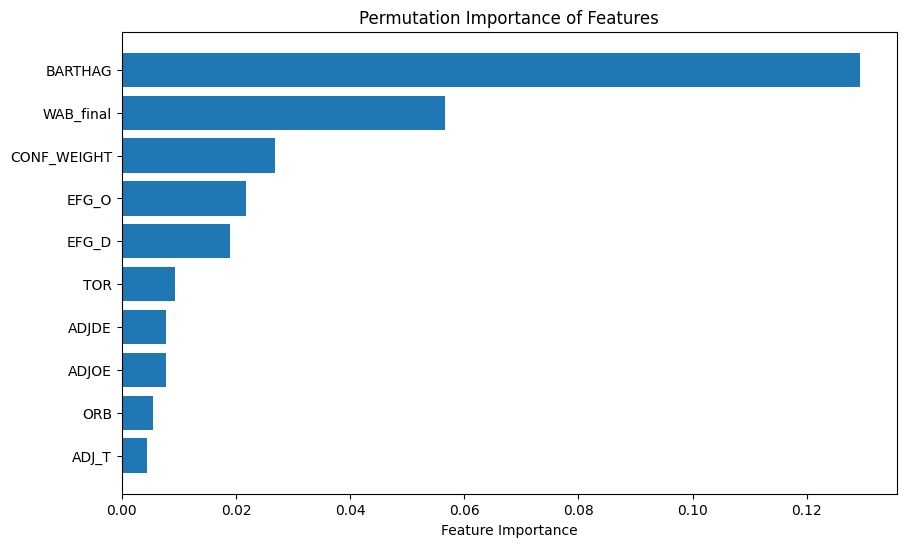

In [ ]:
# ==================== SECTION 7: VISUALIZE FEATURE IMPORTANCE ====================
# This section shows which features were most important in making predictions
# NOTE: THIS CODE MAY TAKE A WHILE TO LOAD, WHICH IS WHY IT IS AT THE BOTTOM.
perm_importance = permutation_importance(model, X_train, y_train, n_repeats=30, random_state=42)
feature_names = X_train.columns
importances = perm_importance.importances_mean
sorted_indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
plt.barh(range(len(sorted_indices)), importances[sorted_indices], align='center')
plt.yticks(range(len(sorted_indices)), [feature_names[i] for i in sorted_indices])
plt.xlabel('Feature Importance')
plt.title('Permutation Importance of Features')
plt.gca().invert_yaxis()
plt.show()